0.958850910770453


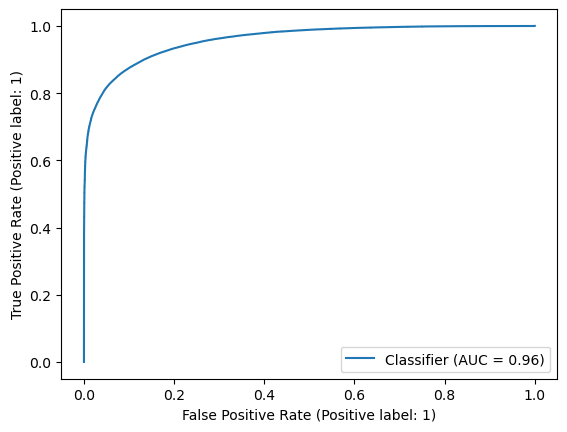

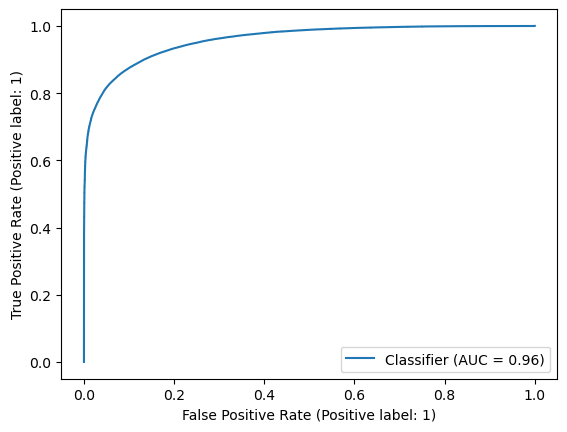

In [49]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics


train_dataset = pd.read_csv("datasets/train.csv")
test_dataset = pd.read_csv("datasets/test.csv")

train_dataset["age"] = train_dataset["age"].fillna(train_dataset["age"].median())
train_dataset["daily_screen_time_hours"] = train_dataset["daily_screen_time_hours"].fillna(train_dataset["daily_screen_time_hours"].median())
train_dataset["social_media_hours"] = train_dataset["social_media_hours"].fillna(train_dataset["social_media_hours"].median())
train_dataset["work_study_hours"] = train_dataset["work_study_hours"].fillna(train_dataset["work_study_hours"].median())
train_dataset["sleep_hours"] = train_dataset["sleep_hours"].fillna(train_dataset["sleep_hours"].median())
train_dataset["notifications_per_day"] = train_dataset["notifications_per_day"].fillna(train_dataset["notifications_per_day"].median())
train_dataset["app_opens_per_day"] = train_dataset["app_opens_per_day"].fillna(train_dataset["app_opens_per_day"].median())
train_dataset["weekend_screen_time"] = train_dataset["weekend_screen_time"].fillna(train_dataset["weekend_screen_time"].median())
test_dataset["age"] = test_dataset["age"].fillna(test_dataset["age"].median())
test_dataset["daily_screen_time_hours"] = test_dataset["daily_screen_time_hours"].fillna(test_dataset["daily_screen_time_hours"].median())
test_dataset["social_media_hours"] = test_dataset["social_media_hours"].fillna(test_dataset["social_media_hours"].median())
test_dataset["work_study_hours"] = test_dataset["work_study_hours"].fillna(test_dataset["work_study_hours"].median())
test_dataset["sleep_hours"] = test_dataset["sleep_hours"].fillna(test_dataset["sleep_hours"].median())
test_dataset["notifications_per_day"] = test_dataset["notifications_per_day"].fillna(test_dataset["notifications_per_day"].median())
test_dataset["app_opens_per_day"] = test_dataset["app_opens_per_day"].fillna(test_dataset["app_opens_per_day"].median())
test_dataset["weekend_screen_time"] = test_dataset["weekend_screen_time"].fillna(test_dataset["weekend_screen_time"].median())

onehot = OneHotEncoder(sparse=False)

columns_that_need_encoding = ["gender","stress_level","academic_work_impact"]
train_encoded_columns = onehot.fit_transform(train_dataset[columns_that_need_encoding])
train_new_columns = pd.DataFrame(train_encoded_columns,columns=onehot.get_feature_names_out(),index=train_dataset.index)
train_after_onehot = pd.concat([train_dataset,train_new_columns],axis=1).drop(columns=columns_that_need_encoding)

test_encoded_columns = onehot.fit_transform(test_dataset[columns_that_need_encoding])
test_new_columns = pd.DataFrame(test_encoded_columns,columns=onehot.get_feature_names_out(),index=test_dataset.index)
test_after_onehot = pd.concat([test_dataset,test_new_columns],axis=1).drop(columns=columns_that_need_encoding)

X = train_after_onehot.drop(columns=["id","addicted_label"])
Y = train_after_onehot["addicted_label"]

X_test = test_after_onehot.drop(columns=["id"])
Y_test = test_after_onehot["id"]

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.25, random_state=42)
model = HistGradientBoostingClassifier(max_depth=12, max_iter=300,learning_rate=0.075)
model.fit(X_train,Y_train)
val_probas = model.predict_proba(X_val)
val_score = roc_auc_score(Y_val,val_probas[:,1])
print(val_score)

display = metrics.RocCurveDisplay.from_predictions(Y_val,val_probas[:,1])

display.plot()

plt.show()

test_probas = model.predict_proba(X_test)

predictions_for_submission = pd.DataFrame({"id":Y_test,"addicted_label":test_probas[:,1]})

predictions_for_submission.to_csv("submission.csv",index=False)